Нет доступа к оригинальному репозиторию курса, поэтому добавил в свой личный
(Левицкий Иван Михайлович M3435)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')
style.use('ggplot')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)

In [6]:
%pip install numpy matplotlib scikit-learn tqdm


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Загрузка и предобработка данных

1. Выберете табличный набор данных для задачи классификации. Предобработайте его: заполните пропуски, нормализуйте и т.д. Разбейте на тренировочную и тестовую часть. Даже если набор данных будет для бинарной классификации, ваша реализация не должна специализироваться под это.

Был выбран классический датасет https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset (тип лесного покрова). Этот набор данных включает информацию о типе деревьев, затененности, расстоянии до ближайших ориентиров (дорог и т. д.), типе почвы и рельефе местности.


In [3]:
class CoverData:
    def __init__(self, path='covtype.csv', train_count=10000, test_count=5000):
        raw = np.genfromtxt(path, delimiter=',', skip_header=1)
        X = raw[:, :-1].astype(np.float64)
        y = raw[:, -1].astype(int) - 1

        X = np.nan_to_num(X, nan=0.0)

        x_tr, x_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_count,
            train_size=train_count, random_state=113, stratify=y
        )

        mu = x_tr.mean(axis=0)
        sigma = x_tr.std(axis=0) + 1e-8

        self.x_train = (x_tr - mu) / sigma
        self.x_test = (x_te - mu) / sigma
        self.unqieue_classes = len(np.unique(y_tr))
        self.y_train = np.eye(self.unqieue_classes)[y_tr]
        self.y_test = np.eye(self.unqieue_classes)[y_te]
        self.input_dim = self.x_train.shape[1]

data = CoverData()
INPUT_DIM = data.input_dim
UNIQUE_CLASSES = data.unqieue_classes
print(f'Train: {data.x_train.shape}, Test: {data.x_test.shape}, Classes: {UNIQUE_CLASSES}')

Train: (10000, 54), Test: (5000, 54), Classes: 7


## Функции активации и базовый класс слоя

2. Реализуйте стандартное обучаемое преобразование: умножение на матрицу, добавление вектора и применение функции «активации». Преобразование должно пересчитывать градиент для входа и параметров. Должны поддерживаться не менее трёх функции «активации». Желательно реализовать: тождественную, ReLU, tanh.

In [17]:
class Activations:
    _fns = {
        'identity': (lambda z: z, lambda z, a: np.ones_like(z)),
        'relu': (lambda z: np.maximum(0, z), lambda z, a: (z > 0).astype(z.dtype)),
        'tanh': (lambda z: np.tanh(z), lambda z, a: 1.0 - a ** 2),
    }

    @classmethod
    def get(cls, name):
        return cls._fns[name]


class Layer:
    def forward(self, x):
        raise NotImplementedError

    def backward(self, grad):
        raise NotImplementedError

    def get_params(self):
        return []

    def get_grads(self):
        return []

## Стандартное линейное преобразование

Ксавье метод

z = x · W + b
a = activation(z)

δ = grad ⊙ activation'(z, a)
dW = xᵀ · δ
db = Σ_batch δ
dx = δ · Wᵀ

In [18]:
class Linear(Layer):
    def __init__(self, in_dim, out_dim, activation='identity'):
        self.W = np.random.randn(in_dim, out_dim) * np.sqrt(2.0 / in_dim) # 
        self.b = np.zeros((1, out_dim))
        self._act, self._act_d = Activations.get(activation)

    def forward(self, x):
        self._x = x
        self._z = x @ self.W + self.b
        self._a = self._act(self._z)
        return self._a

    def backward(self, grad):
        d = grad * self._act_d(self._z, self._a)
        self._dW = self._x.T @ d
        self._db = d.sum(axis=0, keepdims=True)
        return d @ self.W.T

    def get_params(self):
        return [self.W, self.b]

    def get_grads(self):
        return [self._dW, self._db]

## RBF-преобразование

3. Реализуйте модификацию матричного обучаемого преобразования, в котором скалярное произведение заменено на RBF ядро из SVM. То есть каждая координата вектора выхода получается как расстояние вектора входа с соответствующим вектором из матрицы параметров, а затем к нему применяется гауссова функция. Для данного преобразования также необходимо реализовать пересчёт градиента.

rbf_j(x) = exp(−γ · ||x − c_j||²)

In [19]:
class RBFKernel(Layer):
    def __init__(self, in_dim, out_dim, gamma=None, activation='identity'):
        self.C = np.random.randn(out_dim, in_dim) * np.sqrt(2.0 / in_dim)
        self.b = np.zeros((1, out_dim))
        self.gamma = gamma if gamma is not None else 1.0 / in_dim
        self._act, self._act_d = Activations.get(activation)

    def forward(self, x):
        self._x = x
        self._diff = x[:, np.newaxis, :] - self.C[np.newaxis, :, :]
        self._sq = np.sum(self._diff ** 2, axis=2)
        self._z = np.exp(-self.gamma * self._sq)
        self._a = self._act(self._z)
        return self._a

    def backward(self, grad):
        d = grad * self._act_d(self._z, self._a)
        factor = -2.0 * self.gamma * self._z[:, :, np.newaxis] * self._diff
        weighted = d[:, :, np.newaxis] * factor
        self._dC = -weighted.sum(axis=0)
        return weighted.sum(axis=1)

    def get_params(self):
        return [self.C]

    def get_grads(self):
        return [self._dC]

## Обёртка с остаточной связью

4. Реализуйте обёртку над преобразованиями, которая будет добавлять остаточную связь.

In [20]:
class Residual(Layer):
    def __init__(self, layer):
        self._layer = layer

    def forward(self, x):
        out = self._layer.forward(x)
        return out + x

    def backward(self, grad):
        g1 = self._layer.backward(grad)
        return g1 + grad

    def get_params(self):
        return list(self._layer.get_params())

    def get_grads(self):
        return list(self._layer.get_grads())

## SoftArgMaxCrossEntropy

5. Реализуйте функцию ошибки SoftArgMaxCrossEntropy, которая будет стабильно применять к вектору композицию SoftArgMax преобразования и логарифма, для вычисления перекрёстной энтропии с целевым вектором. Данная функция также должна вычислять градиент.

### Шаг 1: Стабилизация (вычитание максимума)

$$\text{shifted}_{ij} = z_{ij} - \max_k(z_{ik})$$

где $z$ — логиты (входные значения).

### Шаг 2: LogSumExp

$$\text{LSE}_i = \log\left(\sum_{j=1}^{C} \exp(\text{shifted}_{ij})\right)$$

### Шаг 3: Лог-вероятности (Log-Softmax)

$$\log(p_{ij}) = \text{shifted}_{ij} - \text{LSE}_i$$

Это эквивалентно:

$$\log(p_{ij}) = z_{ij} - \log\left(\sum_{k=1}^{C} \exp(z_{ik})\right)$$

### Шаг 4: Вероятности (Softmax)

$$p_{ij} = \exp(\log(p_{ij})) = \frac{\exp(z_{ij})}{\sum_{k=1}^{C} \exp(z_{ik})}$$

### Шаг 5: Cross-Entropy Loss

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \sum_{j=1}^{C} y_{ij} \cdot \log(p_{ij})$$

где:
- $N$ — размер батча
- $C$ — количество классов
- $y_{ij}$ — one-hot метки (targets)

---

$$\frac{\partial \mathcal{L}}{\partial z_{ij}} = \frac{p_{ij} - y_{ij}}{N}$$

In [27]:
class SoftArgMaxCrossEntropy:
    def __call__(self, logits, targets):
        self._targets = targets
        shifted = logits - logits.max(axis=1, keepdims=True)
        log_sum_exp = np.log(np.sum(np.exp(shifted), axis=1, keepdims=True))
        self._log_probs = shifted - log_sum_exp
        self._probs = np.exp(self._log_probs)
        return -np.sum(targets * self._log_probs) / logits.shape[0]

    def grad(self):
        return (self._probs - self._targets) / self._targets.shape[0]

## Модель и оптимизатор

6. Реализуйте любой адаптивный градиентный спуск.

In [28]:
class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, x):
        for layer in self.layers:
            x = layer.forward(x)
        return x

    def backward(self, grad):
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def get_params(self):
        out = []
        for l in self.layers:
            out.extend(l.get_params())
        return out

    def get_grads(self):
        out = []
        for l in self.layers:
            out.extend(l.get_grads())
        return out

    def num_params(self):
        return sum(p.size for p in self.get_params())


class Adam:
    def __init__(self, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.lr = lr
        self.b1 = b1
        self.b2 = b2
        self.eps = eps
        self.t = 0
        self.m = None
        self.v = None

    def step(self, params, grads):
        if self.m is None:
            self.m = [np.zeros_like(p) for p in params]
            self.v = [np.zeros_like(p) for p in params]
        self.t += 1
        for i in range(len(params)):
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * grads[i]
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * grads[i] ** 2
            mh = self.m[i] / (1 - self.b1 ** self.t)
            vh = self.v[i] / (1 - self.b2 ** self.t)
            params[i] -= self.lr * mh / (np.sqrt(vh) + self.eps)

## Обучение и визуализация

In [29]:
def run_epoch(model, criterion, opt, x, y, bs):
    n = x.shape[0]
    order = np.random.permutation(n)
    total, cnt = 0.0, 0
    for s in range(0, n, bs):
        bi = order[s:min(s + bs, n)]
        logits = model.forward(x[bi])
        loss = criterion(logits, y[bi])
        model.backward(criterion.grad())
        opt.step(model.get_params(), model.get_grads())
        total += loss
        cnt += 1
    return total / cnt


def predict_batched(model, x, bs=200):
    parts = []
    for s in range(0, x.shape[0], bs):
        logits = model.forward(x[s:s + bs])
        parts.append(logits.argmax(axis=1))
    return np.concatenate(parts)

def score(model, x, y):
    preds = predict_batched(model, x)
    labels = y.argmax(axis=1)
    return np.mean(preds == labels), f1_score(labels, preds, average='macro')

def fit(model, data, epochs=50, lr=1e-3, bs=200):
    criteria = SoftArgMaxCrossEntropy()
    opt = Adam(lr=lr)
    losses = []
    for _ in tqdm(range(epochs)):
        losses.append(run_epoch(model, criteria, opt, data.x_train, data.y_train, bs))
    acc, f1 = score(model, data.x_test, data.y_test)
    return losses, acc, f1


def run_experiment(configs, data, title, epochs=50, lr=1e-3, bs=200):
    results = []
    for name, model in configs:
        print(f'Training: {name}')
        losses, acc, f1 = fit(model, data, epochs=epochs, lr=lr, bs=bs)
        results.append({
            'name': name, 'loss': losses, 'accuracy': acc,
            'f1': f1, 'params': model.num_params()
        })
        print(f'  accuracy={acc:.4f}, f1={f1:.4f}, params={model.num_params()}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14)

    for r in results:
        axes[0].plot(r['loss'], label=r['name'])
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss curves')
    axes[0].legend(fontsize=7)

    x_pos = np.arange(len(results))
    axes[1].bar(x_pos - 0.15, [r['accuracy'] for r in results], 0.3, label='Accuracy')
    axes[1].bar(x_pos + 0.15, [r['f1'] for r in results], 0.3, label='F1 macro')
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([r['name'] for r in results], rotation=25, ha='right', fontsize=7)
    axes[1].set_title('Test metrics')
    axes[1].legend()
    axes[1].set_ylim(0, 1)

    axes[2].scatter([r['params'] for r in results], [r['accuracy'] for r in results], s=80, zorder=5)
    for r in results:
        axes[2].annotate(r['name'], (r['params'], r['accuracy']), fontsize=7, ha='left')
    axes[2].set_xlabel('Parameters')
    axes[2].set_ylabel('Accuracy')
    axes[2].set_title('Accuracy vs params')
    plt.tight_layout()
    plt.show()

    return results

## Эксперимент 1 — стандартные линейные слои

7. Обучите несколько моделей с разным числом стандартных матричных преобразований. Для каждой модели постарайтесь подобрать хорошие гиперпараметры. Также проверьте влияние остаточных связей. На одном графике постройте соответствующие кривые обучения. Замерьте качество классификации (точность или F-меру) на тестовой части, постройте зависимость от числа параметров и преобразований.

Training: 2L: 90


100%|██████████| 60/60 [00:00<00:00, 114.15it/s]


  accuracy=0.7572, f1=0.5940, params=5587
Training: 3L: 100-58


100%|██████████| 60/60 [00:00<00:00, 70.83it/s]


  accuracy=0.7748, f1=0.6362, params=11771
Training: 4L: 90-58-20


...

  accuracy=0.7810, f1=0.6450, params=11555
Training: 3L+Res: 90-90


100%|██████████| 60/60 [00:00<00:00, 61.61it/s]


  accuracy=0.7702, f1=0.6267, params=13777
Training: 4L+Res: 100-100


100%|██████████| 60/60 [00:01<00:00, 37.30it/s]


  accuracy=0.7802, f1=0.6529, params=26407


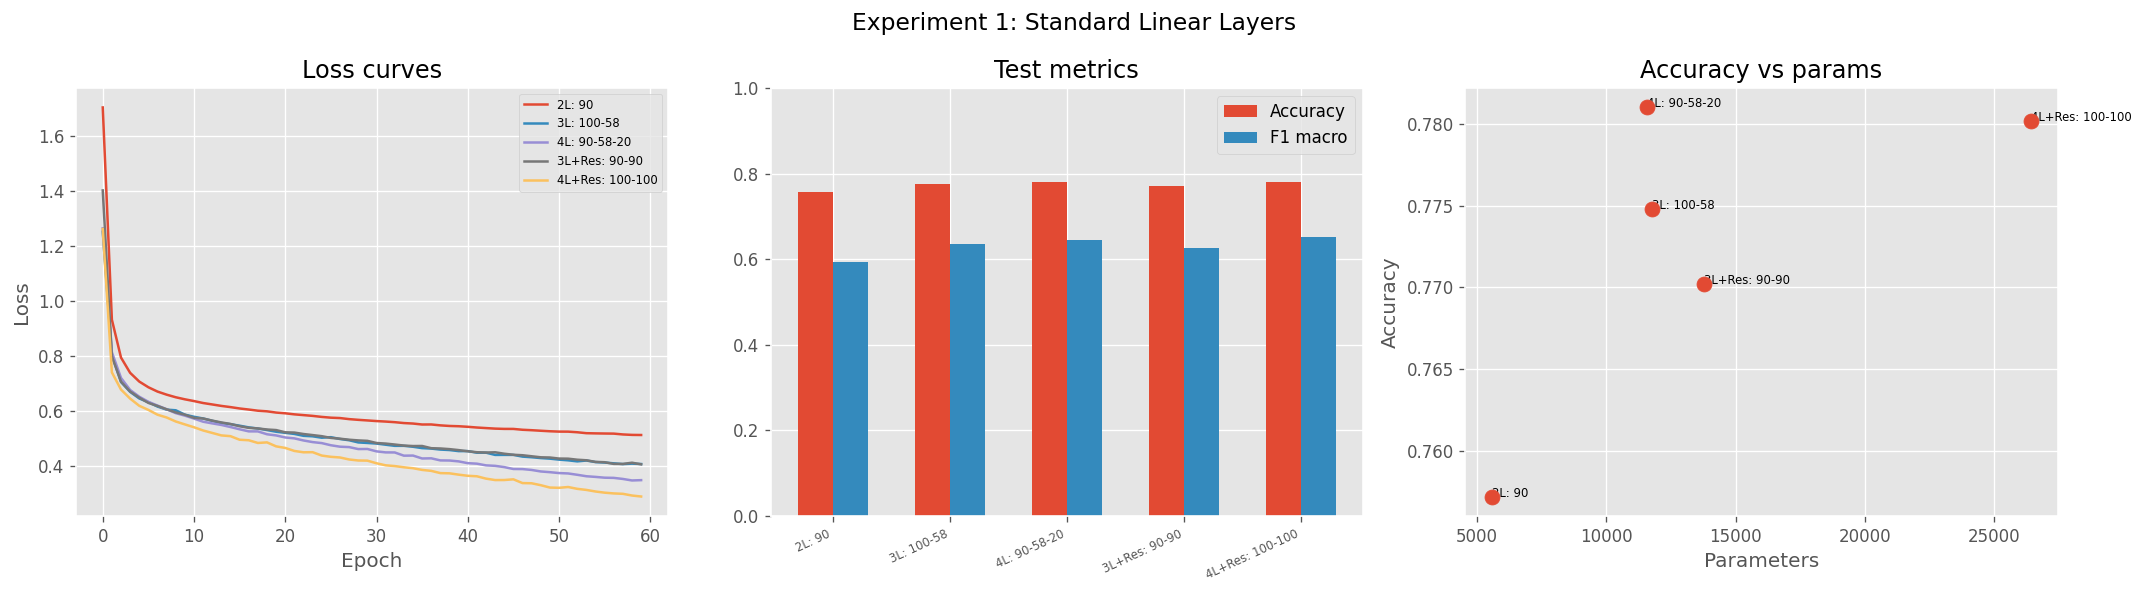

In [30]:
standard_configs = [
    ('2L: 90', Sequential([
        Linear(INPUT_DIM, 90, 'relu'),
        Linear(90, UNIQUE_CLASSES),
    ])),
    ('3L: 100-58', Sequential([
        Linear(INPUT_DIM, 100, 'relu'),
        Linear(100, 58, 'relu'),
        Linear(58, UNIQUE_CLASSES),
    ])),
    ('4L: 90-58-20', Sequential([
        Linear(INPUT_DIM, 90, 'relu'),
        Linear(90, 58, 'tanh'),
        Linear(58, 20, 'relu'),
        Linear(20, UNIQUE_CLASSES),
    ])),
    ('3L+Res: 90-90', Sequential([
        Linear(INPUT_DIM, 90, 'relu'),
        Residual(Linear(90, 90, 'relu')),
        Linear(90, UNIQUE_CLASSES),
    ])),
    ('4L+Res: 100-100', Sequential([
        Linear(INPUT_DIM, 100, 'relu'),
        Residual(Linear(100, 100, 'relu')),
        Residual(Linear(100, 100, 'tanh')),
        Linear(100, UNIQUE_CLASSES),
    ])),
]

res_std = run_experiment(standard_configs, data,
    'Experiment 1: Standard Linear Layers', epochs=60, lr=1e-3)

## Эксперимент 2 — RBF-слои

8. Повторите предыдущий шаг для модифицированного матричного преобразования.

Training: RBF-L: 30


100%|██████████| 50/50 [00:01<00:00, 26.95it/s]


  accuracy=0.6066, f1=0.2292, params=1837
Training: 2RBF-L: 56-10


100%|██████████| 50/50 [00:04<00:00, 12.19it/s]


  accuracy=0.4778, f1=0.1104, params=3661
Training: 2RBF-L: 56-30


100%|██████████| 50/50 [00:05<00:00,  9.06it/s]


  accuracy=0.4780, f1=0.1342, params=4921
Training: RBF-Res-L: 32-32


100%|██████████| 50/50 [00:03<00:00, 14.89it/s]


  accuracy=0.5944, f1=0.2398, params=2983


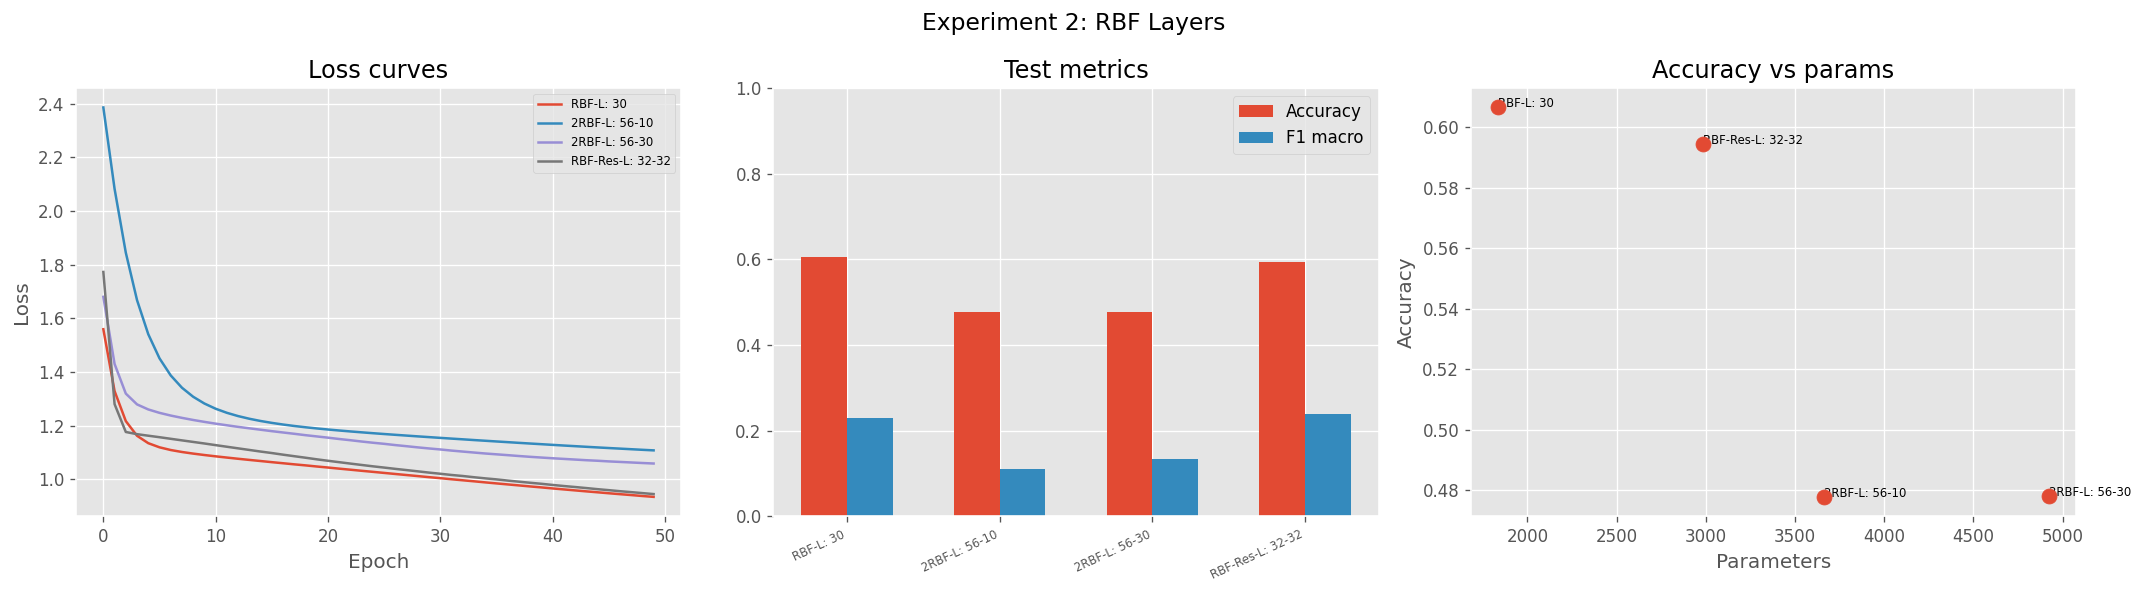

In [31]:
rbf_configs = [
    ('RBF-L: 30', Sequential([
        RBFKernel(INPUT_DIM, 30),
        Linear(30, UNIQUE_CLASSES),
    ])),
    ('2RBF-L: 56-10', Sequential([
        RBFKernel(INPUT_DIM, 56),
        RBFKernel(56, 10),
        Linear(10, UNIQUE_CLASSES),
    ])),
    ('2RBF-L: 56-30', Sequential([
        RBFKernel(INPUT_DIM, 56),
        RBFKernel(56, 30),
        Linear(30, UNIQUE_CLASSES),
    ])),
    ('RBF-Res-L: 32-32', Sequential([
        RBFKernel(INPUT_DIM, 32),
        Residual(RBFKernel(32, 32)),
        Linear(32, UNIQUE_CLASSES),
    ])),
]

res_rbf = run_experiment(rbf_configs, data,
    'Experiment 2: RBF Layers', epochs=50, lr=5e-4)

## Эксперимент 3 — комбинированные модели

9. Постройте модель из комбинации обычных и модифицированных матричных преобразований. Повторите седьмой шаг для них.

Training: L-RBF-L: 50-30


100%|██████████| 50/50 [00:02<00:00, 23.72it/s]


  accuracy=0.7378, f1=0.3997, params=4467
Training: RBF-2L: 30-50


100%|██████████| 50/50 [00:02<00:00, 24.57it/s]


  accuracy=0.7030, f1=0.3851, params=3527
Training: L+Res(RBF)+L: 50-50


100%|██████████| 50/50 [00:03<00:00, 15.71it/s]


  accuracy=0.7478, f1=0.5878, params=5607
Training: RBF+Res(L)+L: 30-30


100%|██████████| 50/50 [00:02<00:00, 24.94it/s]


  accuracy=0.7062, f1=0.3959, params=2767


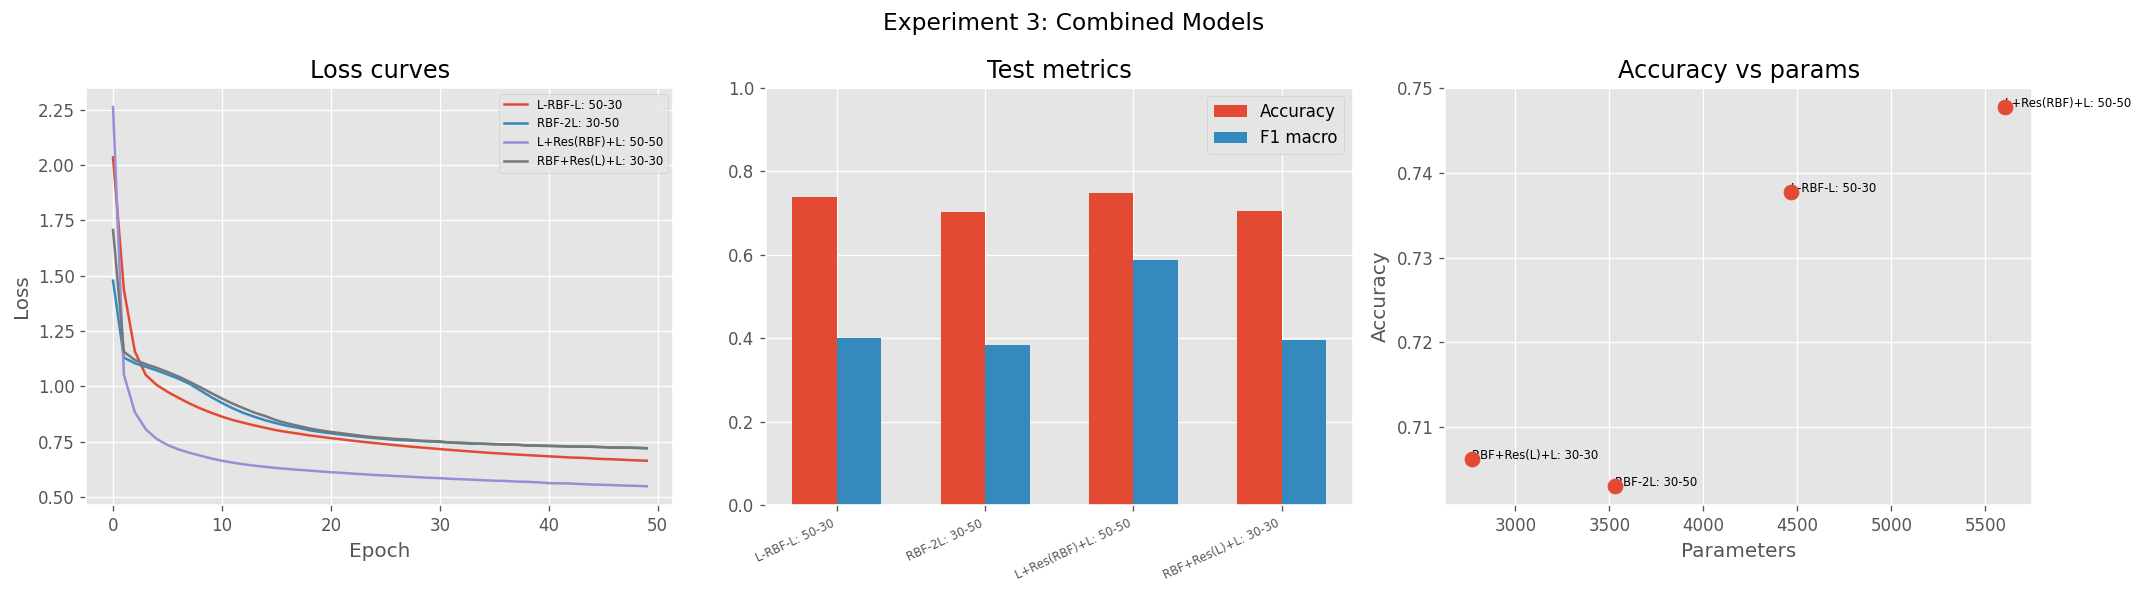

In [32]:
combo_configs = [
    ('L-RBF-L: 50-30', Sequential([
        Linear(INPUT_DIM, 50, 'relu'),
        RBFKernel(50, 30),
        Linear(30, UNIQUE_CLASSES),
    ])),
    ('RBF-2L: 30-50', Sequential([
        RBFKernel(INPUT_DIM, 30),
        Linear(30, 50, 'relu'),
        Linear(50, UNIQUE_CLASSES),
    ])),
    ('L+Res(RBF)+L: 50-50', Sequential([
        Linear(INPUT_DIM, 50, 'relu'),
        Residual(RBFKernel(50, 50)),
        Linear(50, UNIQUE_CLASSES),
    ])),
    ('RBF+Res(L)+L: 30-30', Sequential([
        RBFKernel(INPUT_DIM, 30),
        Residual(Linear(30, 30, 'tanh')),
        Linear(30, UNIQUE_CLASSES),
    ])),
]

res_combo = run_experiment(combo_configs, data,
    'Experiment 3: Combined Models', epochs=50, lr=1e-3)